# Gradient Boosting Ensemble: 3 Boosters × 4 Sub-Models

Стратегия из `example_0.122_score.py` (0.122 PR-AUC на LB), расширенная на 3 бустинга.

**4 подмодели** (для каждого бустинга):
1. **Main** — полная выборка, red vs all
2. **Recent** — события с 2025-02-01 + все помеченные
3. **Suspicious** — (red+yellow) vs green
4. **Red|Suspicious** — red vs yellow (только помеченные)

**Ансамбль**: product ensemble (susp × rg), 3-компонентный бленд на бустинг, мета-бленд в ранговом пространстве.

In [ ]:
from pathlib import Path
import os
import gc
import warnings

import numpy as np
import pandas as pd
import polars as pl

from sklearn.metrics import average_precision_score
from scipy.stats import rankdata
from catboost import CatBoostClassifier, Pool
import lightgbm as lgbm
import xgboost as xgb

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(200)

# --- Paths ---
DATA_DIR = Path("data/raw")
BOOST_CACHE_DIR = Path("cache/boosting")
SUBMISSION_DIR = Path("submission_boosting")
BOOST_CACHE_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

# --- Sampling ---
NEG_SAMPLE_MOD_RECENT = 10   # from 2025-04-01
NEG_SAMPLE_MOD_OLD = 30      # before 2025-04-01
NEG_SAMPLE_BORDER_STR = "2025-04-01 00:00:00"

# --- Validation ---
VAL_START = pd.Timestamp("2025-05-01")
RECENT_BORDER = pd.Timestamp("2025-02-01")

# --- Flags ---
RANDOM_SEED = 42
FORCE_REBUILD_FEATURES = False
FORCE_REBUILD_PRIORS = False
ADD_CATEGORY_PRIORS = True
USE_GPU = True
RETRAIN_ON_FULL_CB = True
RETRAIN_ON_FULL_LGB = True
RETRAIN_ON_FULL_XGB = True

# --- GPU check ---
try:
    import torch
    if torch.cuda.is_available():
        gpu = torch.cuda.get_device_properties(0)
        vram_gb = gpu.total_memory / 1024**3
        print(f"GPU: {gpu.name}, VRAM: {vram_gb:.1f} GB")
    else:
        print("CUDA not available, will use CPU")
        USE_GPU = False
except ImportError:
    print("torch not installed, GPU check skipped")

print("DATA_DIR:", DATA_DIR.resolve())
print("CACHE_DIR:", BOOST_CACHE_DIR.resolve())

GPU: NVIDIA GeForce RTX 3060 Ti, VRAM: 8.0 GB
DATA_DIR: D:\prog\ml\data_fusion\local_df\data\raw
CACHE_DIR: D:\prog\ml\data_fusion\local_df\cache\boosting


In [2]:
# ==================== UTILITY FUNCTIONS ====================

def sigmoid(x):
    x = np.clip(x, -40, 40)
    return 1.0 / (1.0 + np.exp(-x))

def logit(p):
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return np.log(p / (1 - p))

def to_logit(pred, is_probability=True):
    """Convert predictions to logit space. CatBoost RawFormulaVal is already logits."""
    if is_probability:
        return logit(pred)
    return pred

def make_weights(raw_target, event_ts=None):
    """Sample weights: red=10, yellow=2.5, green=1.0 (with recent/old distinction)."""
    w = np.where(raw_target == 1, 10.0, np.where(raw_target == 0, 2.5, 1.0)).astype(np.float32)
    if event_ts is not None:
        ts = pd.to_datetime(event_ts)
        border = pd.Timestamp(NEG_SAMPLE_BORDER_STR)
        green_mask = (raw_target == -1)
        recent_green = green_mask & (ts >= border)
        old_green = green_mask & (ts < border)
        w[recent_green] = 1.8
        w[old_green] = 3.0
    return w

def downcast_pandas(df, cat_cols_set=None):
    """Downcast numeric columns to smallest possible types to save memory."""
    if cat_cols_set is None:
        cat_cols_set = set()
    for c in df.select_dtypes(include=['int64', 'int32']).columns:
        if c in cat_cols_set:
            continue
        col_min, col_max = df[c].min(), df[c].max()
        if pd.isna(col_min):
            continue
        if col_min >= -128 and col_max <= 127:
            df[c] = df[c].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            df[c] = df[c].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            df[c] = df[c].astype(np.int32)
    for c in df.select_dtypes(include=['float64']).columns:
        df[c] = df[c].astype(np.float32)
    return df

def find_best_blend_3(pred_a, pred_b, pred_c, y_true, step=0.02):
    """Grid search for best 3-component blend weights."""
    best_ap, best_w = -1.0, (1.0, 0.0, 0.0)
    for w1 in np.arange(0.0, 1.01, step):
        for w2 in np.arange(0.0, 1.01 - w1, step):
            w3 = 1.0 - w1 - w2
            if w3 < -1e-9:
                continue
            blend = w1 * pred_a + w2 * pred_b + w3 * pred_c
            ap = average_precision_score(y_true, blend)
            if ap > best_ap:
                best_ap = ap
                best_w = (round(float(w1), 4), round(float(w2), 4), round(float(w3), 4))
    return best_w, best_ap

print("Utilities loaded.")

Utilities loaded.


In [3]:
# ==================== COLUMN DEFINITIONS ====================

BASE_COLS = [
    "customer_id", "event_id", "event_dttm", "event_type_nm", "event_desc",
    "channel_indicator_type", "channel_indicator_sub_type", "operaton_amt", "currency_iso_cd",
    "mcc_code", "pos_cd", "timezone", "session_id", "operating_system_type",
    "battery", "device_system_version", "screen_size", "developer_tools",
    "phone_voip_call_state", "web_rdp_connection", "compromised"
]

FINAL_FEATURE_COLS = [
    # raw (mostly categorical)
    "customer_id", "event_type_nm", "event_desc", "channel_indicator_type",
    "channel_indicator_sub_type", "currency_iso_cd", "mcc_code_i", "pos_cd", "timezone",
    "operating_system_type", "phone_voip_call_state", "web_rdp_connection",
    "developer_tools_i", "compromised_i",
    # event numeric
    "amt", "amt_log_abs", "amt_is_negative", "hour", "weekday", "day", "month",
    "is_weekend", "event_day_number", "battery_pct", "os_ver_major", "screen_w",
    "screen_h", "screen_pixels", "screen_ratio", "session_id",
    # sequence
    "cust_prev_events", "cust_prev_amt_mean", "cust_prev_amt_std", "sec_since_prev_event",
    "amt_delta_prev", "cnt_prev_same_type", "cnt_prev_same_desc", "cnt_prev_same_mcc",
    "cnt_prev_same_subtype", "cnt_prev_same_session", "sec_since_prev_same_type",
    "sec_since_prev_same_desc", "events_before_today",
    # dynamic feedback history (strictly from previous labeled events)
    "cust_prev_red_lbl_cnt", "cust_prev_yellow_lbl_cnt", "cust_prev_labeled_cnt",
    "cust_prev_red_lbl_rate", "cust_prev_yellow_lbl_rate", "cust_prev_susp_lbl_rate",
    "cust_prev_any_red_flag", "cust_prev_any_yellow_flag",
    "sec_since_prev_red_lbl", "sec_since_prev_yellow_lbl",
    "cnt_prev_labeled_same_desc", "cnt_prev_red_same_desc_lbl", "cnt_prev_yellow_same_desc_lbl",
    "red_rate_prev_same_desc_lbl",
]

CAT_COLS = [
    "customer_id", "event_type_nm", "event_desc", "channel_indicator_type",
    "channel_indicator_sub_type", "currency_iso_cd", "mcc_code_i", "pos_cd",
    "timezone", "operating_system_type", "phone_voip_call_state", "web_rdp_connection",
    "developer_tools_i", "compromised_i",
]

META_COLS = ["event_id", "period", "event_ts", "is_train_sample", "is_test", "train_target_raw", "target_bin"]

labels_lf = pl.scan_parquet(DATA_DIR / "train_labels.parquet")
labels_df = pl.read_parquet(DATA_DIR / "train_labels.parquet")
print("Labels:", labels_df.shape)

Labels: (87514, 3)


In [4]:
# ==================== FEATURE ENGINEERING ====================

def _period_frames_for_part(part_id: int) -> pl.LazyFrame:
    custs_lf = (
        pl.scan_parquet(DATA_DIR / f"pretrain_part_{part_id}.parquet")
        .select("customer_id")
        .unique()
    )

    pretrain_lf = (
        pl.scan_parquet(DATA_DIR / f"pretrain_part_{part_id}.parquet")
        .select(BASE_COLS)
        .with_columns(pl.lit("pretrain").alias("period"))
    )
    train_lf = (
        pl.scan_parquet(DATA_DIR / f"train_part_{part_id}.parquet")
        .select(BASE_COLS)
        .with_columns(pl.lit("train").alias("period"))
    )
    pretest_lf = (
        pl.scan_parquet(DATA_DIR / "pretest.parquet")
        .select(BASE_COLS)
        .unique()  # FIX: 130,360 duplicate rows in pretest
        .join(custs_lf, on="customer_id", how="inner")
        .with_columns(pl.lit("pretest").alias("period"))
    )
    test_lf = (
        pl.scan_parquet(DATA_DIR / "test.parquet")
        .select(BASE_COLS)
        .join(custs_lf, on="customer_id", how="inner")
        .with_columns(pl.lit("test").alias("period"))
    )

    return pl.concat([pretrain_lf, train_lf, pretest_lf, test_lf], how="vertical_relaxed")


def build_features_for_part(part_id: int, force: bool = False) -> Path:
    out_path = BOOST_CACHE_DIR / f"features_part_{part_id}.parquet"
    if out_path.exists() and (not force):
        print(f"[part {part_id}] use cache -> {out_path.name}")
        return out_path

    print(f"[part {part_id}] building features...")
    lf = _period_frames_for_part(part_id)

    lf = (
        lf.with_columns([
            pl.col("event_dttm").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False).alias("event_ts"),
            pl.col("operaton_amt").cast(pl.Float64).alias("amt"),
            pl.col("session_id").cast(pl.Int64, strict=False).fill_null(-1).alias("session_id"),

            pl.col("event_type_nm").cast(pl.Int32, strict=False).fill_null(-1).alias("event_type_nm"),
            pl.col("event_desc").cast(pl.Int32, strict=False).fill_null(-1).alias("event_desc"),
            pl.col("channel_indicator_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_type"),
            pl.col("channel_indicator_sub_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_sub_type"),
            pl.col("currency_iso_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("currency_iso_cd"),
            pl.col("pos_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("pos_cd"),
            pl.col("timezone").cast(pl.Int32, strict=False).fill_null(-1).alias("timezone"),
            pl.col("operating_system_type").cast(pl.Int16, strict=False).fill_null(-1).alias("operating_system_type"),
            pl.col("phone_voip_call_state").cast(pl.Int8, strict=False).fill_null(-1).alias("phone_voip_call_state"),
            pl.col("web_rdp_connection").cast(pl.Int8, strict=False).fill_null(-1).alias("web_rdp_connection"),

            pl.col("mcc_code").cast(pl.Int32, strict=False).fill_null(-1).alias("mcc_code_i"),
            pl.col("battery").str.extract(r"(\d{1,3})", 1).cast(pl.Int16, strict=False).fill_null(-1).alias("battery_pct"),
            pl.col("device_system_version").str.extract(r"^(\d+)", 1).cast(pl.Int16, strict=False).fill_null(-1).alias("os_ver_major"),
            pl.col("screen_size").str.extract(r"^(\d+)", 1).cast(pl.Int16, strict=False).fill_null(-1).alias("screen_w"),
            pl.col("screen_size").str.extract(r"x(\d+)$", 1).cast(pl.Int16, strict=False).fill_null(-1).alias("screen_h"),
            pl.col("developer_tools").cast(pl.Int8, strict=False).fill_null(-1).alias("developer_tools_i"),
            pl.col("compromised").cast(pl.Int8, strict=False).fill_null(-1).alias("compromised_i"),
        ])
        .drop(["event_dttm", "operaton_amt", "mcc_code", "battery", "device_system_version", "screen_size", "developer_tools", "compromised"])
        .sort(["customer_id", "event_ts", "event_id"])
    )

    lf = lf.join(labels_lf, on="event_id", how="left")
    lf = lf.with_columns([
        pl.when(pl.col("period") == "train")
          .then(pl.when(pl.col("target").is_null()).then(pl.lit(-1)).otherwise(pl.col("target")))
          .otherwise(pl.lit(None))
          .alias("train_target_raw")
    ])

    border_expr = pl.lit(NEG_SAMPLE_BORDER_STR).str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False)
    lf = lf.with_columns([
        ((pl.col("period") == "train") &
         (pl.col("train_target_raw") == -1) &
         (((pl.col("event_ts") >= border_expr) & ((pl.struct(["event_id", "customer_id"]).hash(seed=RANDOM_SEED) % NEG_SAMPLE_MOD_RECENT) == 0)) |
          ((pl.col("event_ts") < border_expr) & ((pl.struct(["event_id", "customer_id"]).hash(seed=RANDOM_SEED + 17) % NEG_SAMPLE_MOD_OLD) == 0))))
          .alias("keep_green")
    ])
    lf = lf.with_columns([
        ((pl.col("period") == "train") & ((pl.col("train_target_raw") != -1) | pl.col("keep_green"))).alias("is_train_sample"),
        (pl.col("period") == "test").alias("is_test"),

        pl.col("event_ts").dt.hour().cast(pl.Int8).alias("hour"),
        pl.col("event_ts").dt.weekday().cast(pl.Int8).alias("weekday"),
        pl.col("event_ts").dt.day().cast(pl.Int8).alias("day"),
        pl.col("event_ts").dt.month().cast(pl.Int8).alias("month"),
        (pl.col("event_ts").dt.weekday() >= 5).cast(pl.Int8).alias("is_weekend"),
        (pl.col("event_ts").dt.epoch("s") // 86400).cast(pl.Int32).alias("event_day_number"),
        pl.col("event_ts").dt.date().alias("event_date"),

        pl.col("amt").abs().log1p().cast(pl.Float32).alias("amt_log_abs"),
        (pl.col("amt") < 0).cast(pl.Int8).alias("amt_is_negative"),
        (pl.col("screen_w").cast(pl.Int32) * pl.col("screen_h").cast(pl.Int32)).alias("screen_pixels"),
        pl.when((pl.col("screen_h") > 0) & (pl.col("screen_w") > 0))
          .then(pl.col("screen_w").cast(pl.Float32) / pl.col("screen_h").cast(pl.Float32))
          .otherwise(0.0)
          .alias("screen_ratio"),
    ])

    # feedback flags (known only for train period), then lagged/cumulative stats
    lf = lf.with_columns([
        ((pl.col("period") == "train") & (pl.col("train_target_raw") == 1)).cast(pl.Int8).alias("is_red_lbl"),
        ((pl.col("period") == "train") & (pl.col("train_target_raw") == 0)).cast(pl.Int8).alias("is_yellow_lbl"),
    ])
    lf = lf.with_columns([
        (pl.col("is_red_lbl") + pl.col("is_yellow_lbl")).cast(pl.Int8).alias("is_labeled_fb")
    ])

    lf = lf.with_columns([
        pl.cum_count("event_id").over("customer_id").cast(pl.Int32).alias("cust_event_idx"),
        pl.col("amt").cum_sum().over("customer_id").alias("cust_cum_amt"),
        (pl.col("amt") * pl.col("amt")).cum_sum().over("customer_id").alias("cust_cum_amt_sq"),
        pl.col("event_ts").shift(1).over("customer_id").alias("prev_event_ts"),
        pl.col("amt").shift(1).over("customer_id").alias("prev_amt"),

        (pl.cum_count("event_id").over(["customer_id", "event_type_nm"]) - 1).cast(pl.Int16).alias("cnt_prev_same_type"),
        (pl.cum_count("event_id").over(["customer_id", "event_desc"]) - 1).cast(pl.Int16).alias("cnt_prev_same_desc"),
        (pl.cum_count("event_id").over(["customer_id", "mcc_code_i"]) - 1).cast(pl.Int16).alias("cnt_prev_same_mcc"),
        (pl.cum_count("event_id").over(["customer_id", "channel_indicator_sub_type"]) - 1).cast(pl.Int16).alias("cnt_prev_same_subtype"),
        (pl.cum_count("event_id").over(["customer_id", "session_id"]) - 1).cast(pl.Int16).alias("cnt_prev_same_session"),

        pl.col("event_ts").shift(1).over(["customer_id", "event_type_nm"]).alias("prev_same_type_ts"),
        pl.col("event_ts").shift(1).over(["customer_id", "event_desc"]).alias("prev_same_desc_ts"),

        pl.col("is_red_lbl").cum_sum().over("customer_id").cast(pl.Int32).alias("cust_red_lbl_cum"),
        pl.col("is_yellow_lbl").cum_sum().over("customer_id").cast(pl.Int32).alias("cust_yellow_lbl_cum"),
        pl.col("is_labeled_fb").cum_sum().over("customer_id").cast(pl.Int32).alias("cust_labeled_fb_cum"),

        pl.col("is_red_lbl").cum_sum().over(["customer_id", "event_desc"]).cast(pl.Int16).alias("desc_red_lbl_cum"),
        pl.col("is_yellow_lbl").cum_sum().over(["customer_id", "event_desc"]).cast(pl.Int16).alias("desc_yellow_lbl_cum"),
        pl.col("is_labeled_fb").cum_sum().over(["customer_id", "event_desc"]).cast(pl.Int16).alias("desc_labeled_fb_cum"),

        pl.when(pl.col("is_red_lbl") == 1).then(pl.col("event_ts")).otherwise(None).alias("red_lbl_ts"),
        pl.when(pl.col("is_yellow_lbl") == 1).then(pl.col("event_ts")).otherwise(None).alias("yellow_lbl_ts"),
    ])

    lf = lf.with_columns([
        pl.col("red_lbl_ts").shift(1).over("customer_id").forward_fill().over("customer_id").alias("prev_red_lbl_ts"),
        pl.col("yellow_lbl_ts").shift(1).over("customer_id").forward_fill().over("customer_id").alias("prev_yellow_lbl_ts"),
    ])

    lf = lf.with_columns([
        (pl.col("cust_event_idx") - 1).cast(pl.Int32).alias("cust_prev_events"),
        pl.when(pl.col("cust_event_idx") > 1)
          .then((pl.col("cust_cum_amt") - pl.col("amt")) / (pl.col("cust_event_idx") - 1))
          .otherwise(0.0)
          .cast(pl.Float32)
          .alias("cust_prev_amt_mean"),
        pl.when(pl.col("prev_event_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_event_ts")).dt.total_seconds())
          .otherwise(-1)
          .cast(pl.Int32)
          .alias("sec_since_prev_event"),
        (pl.col("amt") - pl.col("prev_amt").fill_null(0.0)).cast(pl.Float32).alias("amt_delta_prev"),
        pl.when(pl.col("prev_same_type_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_same_type_ts")).dt.total_seconds())
          .otherwise(-1)
          .cast(pl.Int32)
          .alias("sec_since_prev_same_type"),
        pl.when(pl.col("prev_same_desc_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_same_desc_ts")).dt.total_seconds())
          .otherwise(-1)
          .cast(pl.Int32)
          .alias("sec_since_prev_same_desc"),
        (pl.cum_count("event_id").over(["customer_id", "event_date"]) - 1).cast(pl.Int16).alias("events_before_today"),

        (pl.col("cust_red_lbl_cum") - pl.col("is_red_lbl")).cast(pl.Int32).alias("cust_prev_red_lbl_cnt"),
        (pl.col("cust_yellow_lbl_cum") - pl.col("is_yellow_lbl")).cast(pl.Int32).alias("cust_prev_yellow_lbl_cnt"),
        (pl.col("cust_labeled_fb_cum") - pl.col("is_labeled_fb")).cast(pl.Int32).alias("cust_prev_labeled_cnt"),

        (pl.col("desc_labeled_fb_cum") - pl.col("is_labeled_fb")).cast(pl.Int16).alias("cnt_prev_labeled_same_desc"),
        (pl.col("desc_red_lbl_cum") - pl.col("is_red_lbl")).cast(pl.Int16).alias("cnt_prev_red_same_desc_lbl"),
        (pl.col("desc_yellow_lbl_cum") - pl.col("is_yellow_lbl")).cast(pl.Int16).alias("cnt_prev_yellow_same_desc_lbl"),

        pl.when(pl.col("prev_red_lbl_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_red_lbl_ts")).dt.total_seconds())
          .otherwise(-1)
          .cast(pl.Int32)
          .alias("sec_since_prev_red_lbl"),
        pl.when(pl.col("prev_yellow_lbl_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_yellow_lbl_ts")).dt.total_seconds())
          .otherwise(-1)
          .cast(pl.Int32)
          .alias("sec_since_prev_yellow_lbl"),
    ])

    lf = lf.with_columns([
        pl.when(pl.col("cust_event_idx") > 2)
          .then(
              (
                  ((pl.col("cust_cum_amt_sq") - pl.col("amt") * pl.col("amt")) / (pl.col("cust_event_idx") - 1))
                  - (pl.col("cust_prev_amt_mean") * pl.col("cust_prev_amt_mean"))
              )
              .clip(lower_bound=0)
              .sqrt()
          )
          .otherwise(0.0)
          .cast(pl.Float32)
          .alias("cust_prev_amt_std"),

        ((pl.col("cust_prev_red_lbl_cnt") + 0.1) / (pl.col("cust_prev_labeled_cnt") + 1.0)).cast(pl.Float32).alias("cust_prev_red_lbl_rate"),
        ((pl.col("cust_prev_yellow_lbl_cnt") + 0.1) / (pl.col("cust_prev_labeled_cnt") + 1.0)).cast(pl.Float32).alias("cust_prev_yellow_lbl_rate"),
        (((pl.col("cust_prev_red_lbl_cnt") + pl.col("cust_prev_yellow_lbl_cnt")) + 0.1) / (pl.col("cust_prev_events") + 1.0)).cast(pl.Float32).alias("cust_prev_susp_lbl_rate"),
        (pl.col("cust_prev_red_lbl_cnt") > 0).cast(pl.Int8).alias("cust_prev_any_red_flag"),
        (pl.col("cust_prev_yellow_lbl_cnt") > 0).cast(pl.Int8).alias("cust_prev_any_yellow_flag"),
        ((pl.col("cnt_prev_red_same_desc_lbl") + 0.1) / (pl.col("cnt_prev_labeled_same_desc") + 1.0)).cast(pl.Float32).alias("red_rate_prev_same_desc_lbl"),
    ])

    lf = lf.with_columns([
        pl.when(pl.col("is_train_sample")).then((pl.col("train_target_raw") == 1).cast(pl.Int8)).otherwise(pl.lit(None)).alias("target_bin")
    ])

    select_cols = ["event_id", "period", "event_ts", "is_train_sample", "is_test", "train_target_raw", "target_bin"] + FINAL_FEATURE_COLS

    out_df = (
        lf.filter(pl.col("is_train_sample") | pl.col("is_test"))
          .select(select_cols)
          .collect()
    )

    out_df.write_parquet(out_path, compression="zstd")

    n_train = int(out_df.filter(pl.col("is_train_sample")).height)
    n_test = int(out_df.filter(pl.col("is_test")).height)
    print(f"[part {part_id}] done: rows={out_df.height:,}, train_sample={n_train:,}, test={n_test:,}")

    del out_df
    gc.collect()
    return out_path

In [5]:
# ==================== PRIOR TABLES ====================

PRIOR_COL_DEFS = {
    "event_desc": pl.col("event_desc").cast(pl.Int32, strict=False).fill_null(-1).alias("event_desc"),
    "mcc_code_i": pl.col("mcc_code").cast(pl.Int32, strict=False).fill_null(-1).alias("mcc_code_i"),
    "timezone": pl.col("timezone").cast(pl.Int32, strict=False).fill_null(-1).alias("timezone"),
    "operating_system_type": pl.col("operating_system_type").cast(pl.Int16, strict=False).fill_null(-1).alias("operating_system_type"),
    "channel_indicator_sub_type": pl.col("channel_indicator_sub_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_sub_type"),
    "event_type_nm": pl.col("event_type_nm").cast(pl.Int32, strict=False).fill_null(-1).alias("event_type_nm"),
    "pos_cd": pl.col("pos_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("pos_cd"),
}


def _train_scan_with_expr(expr: pl.Expr, key_name: str) -> pl.LazyFrame:
    return pl.concat([
        pl.scan_parquet(DATA_DIR / f"train_part_{i}.parquet")
          .select([pl.col("event_id"), expr])
        for i in [1, 2, 3]
    ], how="vertical_relaxed")


def build_prior_table(key_name: str, expr: pl.Expr, force: bool = False) -> pl.DataFrame:
    out_path = BOOST_CACHE_DIR / f"prior_{key_name}.parquet"
    if out_path.exists() and (not force):
        return pl.read_parquet(out_path)

    print(f"Building priors for: {key_name}")
    lf = _train_scan_with_expr(expr, key_name)

    cnt_col = f"prior_{key_name}_cnt"
    lbl_cnt_col = f"prior_{key_name}_lbl_cnt"
    red_cnt_col = f"prior_{key_name}_red_cnt"

    total = lf.group_by(key_name).len().rename({"len": cnt_col})
    labeled = (
        lf.join(labels_lf, on="event_id", how="inner")
          .group_by(key_name)
          .agg([
              pl.len().alias(lbl_cnt_col),
              pl.sum("target").cast(pl.Float64).alias(red_cnt_col),
          ])
    )

    prior = (
        total.join(labeled, on=key_name, how="left")
             .with_columns([
                 pl.col(lbl_cnt_col).fill_null(0.0),
                 pl.col(red_cnt_col).fill_null(0.0),
             ])
             .with_columns([
                 ((pl.col(red_cnt_col) + 1.0) / (pl.col(cnt_col) + 200.0)).cast(pl.Float32).alias(f"prior_{key_name}_red_rate_all"),
                 ((pl.col(lbl_cnt_col) + 1.0) / (pl.col(cnt_col) + 200.0)).cast(pl.Float32).alias(f"prior_{key_name}_labeled_rate_all"),
                 ((pl.col(red_cnt_col) + 1.0) / (pl.col(lbl_cnt_col) + 2.0)).cast(pl.Float32).alias(f"prior_{key_name}_red_share_labeled"),
             ])
             .select([
                 key_name,
                 cnt_col,
                 f"prior_{key_name}_red_rate_all",
                 f"prior_{key_name}_labeled_rate_all",
                 f"prior_{key_name}_red_share_labeled",
             ])
             .collect()
    )

    prior.write_parquet(out_path, compression="zstd")
    return prior

print("Prior table functions defined.")

Prior table functions defined.


In [6]:
# ==================== BUILD & LOAD FEATURES ====================

feature_paths = []
for part_id in [1, 2, 3]:
    path = build_features_for_part(part_id, force=FORCE_REBUILD_FEATURES)
    feature_paths.append(path)

features = pl.concat([pl.scan_parquet(p) for p in feature_paths], how="vertical_relaxed").collect()

print("Feature table shape:", features.shape)
print("Train sample rows:", features.filter(pl.col("is_train_sample")).height)
print("Test rows:", features.filter(pl.col("is_test")).height)

# --- Join prior tables ---
prior_feature_cols = []
if ADD_CATEGORY_PRIORS:
    for key_name, expr in PRIOR_COL_DEFS.items():
        prior_df = build_prior_table(key_name, expr, force=FORCE_REBUILD_PRIORS)
        features = features.join(prior_df, on=key_name, how="left")
        prior_feature_cols.extend([c for c in prior_df.columns if c != key_name])

    fill_exprs = [pl.col(c).fill_null(pl.col(c).mean()).alias(c) for c in prior_feature_cols]
    if fill_exprs:
        features = features.with_columns(fill_exprs)

print("Feature table after priors:", features.shape)

[part 1] use cache -> features_part_1.parquet
[part 2] use cache -> features_part_2.parquet
[part 3] use cache -> features_part_3.parquet
Feature table shape: (5222515, 64)
Train sample rows: 4588832
Test rows: 633683
Feature table after priors: (5222515, 92)


## Data Preparation

In [7]:
# ==================== DATA PREPARATION ====================

train_pl = features.filter(pl.col("is_train_sample")).with_columns([
    pl.col("target_bin").cast(pl.Int8),
])
test_pl = features.filter(pl.col("is_test"))

print("Train sample:", train_pl.shape)
print("Test rows:", test_pl.shape)

train_df = train_pl.to_pandas()
test_df = test_pl.to_pandas()

del features, train_pl, test_pl
gc.collect()

train_df["event_ts"] = pd.to_datetime(train_df["event_ts"])
test_df["event_ts"] = pd.to_datetime(test_df["event_ts"])

feature_cols = [c for c in train_df.columns if c not in META_COLS]
if ADD_CATEGORY_PRIORS:
    feature_cols = [c for c in feature_cols if c != "target"]

# ensure no leakage columns in features
for bad_col in ["target", "keep_green", "event_date"]:
    if bad_col in feature_cols:
        feature_cols.remove(bad_col)

cat_cols = [c for c in CAT_COLS if c in feature_cols]
num_cols = [c for c in feature_cols if c not in cat_cols]

for c in cat_cols:
    train_df[c] = train_df[c].fillna(-1).astype(np.int64)
    test_df[c] = test_df[c].fillna(-1).astype(np.int64)

# robust fill for numeric columns
medians = train_df[num_cols].median(numeric_only=True)
train_df[num_cols] = train_df[num_cols].fillna(medians)
test_df[num_cols] = test_df[num_cols].fillna(medians)

# downcast for memory savings
train_df = downcast_pandas(train_df, cat_cols_set=set(cat_cols))
test_df = downcast_pandas(test_df, cat_cols_set=set(cat_cols))

# keep chronological order for validation split
train_df = train_df.sort_values("event_ts").reset_index(drop=True)

print("Features:", len(feature_cols))
print("Categorical features:", len(cat_cols))
print("Numerical features:", len(num_cols))
print(f"Train memory: {train_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"Test memory: {test_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Train sample: (4588832, 92)
Test rows: (633683, 92)
Features: 85
Categorical features: 14
Numerical features: 71
Train memory: 1641.6 MB
Test memory: 229.6 MB


## Train/Val Split & Sub-model Data

In [8]:
# ==================== TRAIN / VAL SPLIT & SUB-MODEL DATA ====================

val_mask = (train_df["event_ts"] >= VAL_START).values
raw_target = train_df["train_target_raw"].values

# --- MAIN model data ---
X_all = train_df[feature_cols]
y_all = train_df["target_bin"].astype(np.int8).values
w_all = make_weights(raw_target, train_df["event_ts"].values)

X_main_tr = X_all.loc[~val_mask]
y_main_tr = y_all[~val_mask]
w_main_tr = w_all[~val_mask]

X_main_val = X_all.loc[val_mask]
y_main_val = y_all[val_mask]
w_main_val = w_all[val_mask]

print(f"Main train: {len(X_main_tr):,}  Main val: {len(X_main_val):,}")

# --- RECENT model data ---
recent_mask = ((train_df["event_ts"] >= RECENT_BORDER) | (raw_target != -1)).values
recent_train_mask = recent_mask & (~val_mask)
recent_val_mask = recent_mask & val_mask

X_recent_tr = train_df.loc[recent_train_mask, feature_cols]
y_recent_tr = y_all[recent_train_mask]
w_recent_tr = make_weights(raw_target[recent_train_mask], train_df.loc[recent_train_mask, "event_ts"].values)

X_recent_val = train_df.loc[recent_val_mask, feature_cols]
y_recent_val = y_all[recent_val_mask]
w_recent_val = make_weights(raw_target[recent_val_mask], train_df.loc[recent_val_mask, "event_ts"].values)

print(f"Recent train: {len(X_recent_tr):,}  Recent val: {len(X_recent_val):,}")

# --- SUSPICIOUS model data: (red + yellow) vs green ---
y_susp = (raw_target != -1).astype(np.int8)
w_susp = np.where(raw_target != -1, 6.0, 1.2).astype(np.float32)

X_susp_tr = X_all.loc[~val_mask]
y_susp_tr = y_susp[~val_mask]
w_susp_tr = w_susp[~val_mask]

X_susp_val = X_all.loc[val_mask]
y_susp_val = y_susp[val_mask]
w_susp_val = w_susp[val_mask]

print(f"Susp train: {len(X_susp_tr):,}  Susp val: {len(X_susp_val):,}")

# --- RED|SUSPICIOUS model data: red vs yellow (labeled only) ---
labeled_mask = (raw_target != -1)
labeled_train_mask = labeled_mask & (~val_mask)
labeled_val_mask = labeled_mask & val_mask

y_rg = train_df.loc[labeled_mask, "target_bin"].astype(np.int8).values
w_rg = np.where(raw_target[labeled_mask] == 1, 2.2, 1.0).astype(np.float32)

X_rg_tr = train_df.loc[labeled_train_mask, feature_cols]
y_rg_tr = train_df.loc[labeled_train_mask, "target_bin"].astype(np.int8).values
w_rg_tr = np.where(raw_target[labeled_train_mask] == 1, 2.2, 1.0).astype(np.float32)

X_rg_val = train_df.loc[labeled_val_mask, feature_cols]
y_rg_val = train_df.loc[labeled_val_mask, "target_bin"].astype(np.int8).values
w_rg_val = np.where(raw_target[labeled_val_mask] == 1, 2.2, 1.0).astype(np.float32)

print(f"R|S train: {len(X_rg_tr):,}  R|S val: {len(X_rg_val):,}")

# test data
X_test = test_df[feature_cols]
print(f"Test: {len(X_test):,}")

Main train: 3,317,752  Main val: 1,271,080
Recent train: 1,962,395  Recent val: 1,271,080
Susp train: 3,317,752  Susp val: 1,271,080
R|S train: 74,084  R|S val: 13,430
Test: 633,683


## CatBoost — 4 Sub-Models

GPU: `task_type="GPU"`. Ограничения (`gpu_ram_part`, `border_count`, `max_ctr_complexity`) закомментированы — раскомментировать при OOM.

In [9]:
# ==================== CATBOOST: TRAINING FUNCTIONS ====================

def fit_catboost_with_holdout(X_tr, y_tr, w_tr, X_val, y_val, w_val, cat_cols, params, use_gpu=True):
    params = params.copy()
    params.update({
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": RANDOM_SEED,
        "allow_writing_files": False,
        "verbose": 200,
        "metric_period": 100,
        # --- GPU memory limits (uncomment if OOM) ---
        # "gpu_ram_part": 0.8,
        # "border_count": 64,
        # "max_ctr_complexity": 1,
    })

    if use_gpu:
        params.update({"task_type": "GPU", "devices": "0"})
    else:
        params.update({"task_type": "CPU", "thread_count": max(1, (os.cpu_count() or 4) - 1)})

    train_pool = Pool(X_tr, y_tr, weight=w_tr, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, weight=w_val, cat_features=cat_cols)

    try:
        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
    except Exception as e:
        print("GPU fit failed, fallback to CPU:", e)
        params.pop("devices", None)
        params["task_type"] = "CPU"
        params["thread_count"] = max(1, (os.cpu_count() or 4) - 1)
        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    val_raw = model.predict(val_pool, prediction_type="RawFormulaVal")
    val_ap = average_precision_score(y_val, val_raw)
    best_iter = model.get_best_iteration()
    if best_iter is None or best_iter <= 0:
        best_iter = params.get("iterations", 1000)

    print(f"best_iter={best_iter}, val_pr_auc={val_ap:.6f}")
    return model, best_iter, val_ap, params


def refit_full_catboost(X, y, w, cat_cols, base_params, best_iter):
    params = base_params.copy()
    params.pop("od_type", None)
    params.pop("od_wait", None)
    params["iterations"] = int(max(300, best_iter))

    y_arr = np.asarray(y)
    w_arr = np.asarray(w, dtype=np.float32)
    if w_arr.ndim == 0:
        w_arr = np.full(shape=(len(y_arr),), fill_value=float(w_arr), dtype=np.float32)
    elif w_arr.shape[0] != len(y_arr):
        fill_value = float(np.nanmean(w_arr)) if w_arr.size > 0 else 1.0
        if not np.isfinite(fill_value):
            fill_value = 1.0
        w_arr = np.full(shape=(len(y_arr),), fill_value=fill_value, dtype=np.float32)

    pool = Pool(X, y_arr, weight=w_arr, cat_features=cat_cols)
    model = CatBoostClassifier(**params)
    model.fit(pool, verbose=200)
    return model

print("CatBoost functions defined.")

CatBoost functions defined.


In [10]:
# ==================== CATBOOST: 4 SUB-MODELS ====================

CB_PARAMS_MAIN = {
    "iterations": 5000,
    "learning_rate": 0.05,
    "depth": 8,
    "l2_leaf_reg": 8.0,
    "od_type": "Iter",
    "od_wait": 300,
}

CB_PARAMS_AUX = {
    "iterations": 5000,
    "learning_rate": 0.05,
    "depth": 8,
    "l2_leaf_reg": 8.0,
    "od_type": "Iter",
    "od_wait": 250,
}

# --- 1. Main model ---
print("=" * 60)
print("CatBoost MAIN model")
print("=" * 60)
model_cb_main, best_iter_cb_main, ap_cb_main, used_params_cb_main = fit_catboost_with_holdout(
    X_main_tr, y_main_tr, w_main_tr,
    X_main_val, y_main_val, w_main_val,
    cat_cols=cat_cols, params=CB_PARAMS_MAIN, use_gpu=USE_GPU,
)
model_cb_main.save_model(str(BOOST_CACHE_DIR / "cb_main.cbm"))
pred_cb_main_val = model_cb_main.predict(Pool(X_main_val, cat_features=cat_cols), prediction_type="RawFormulaVal")
del model_cb_main; gc.collect()

# --- 2. Recent model ---
print("\n" + "=" * 60)
print("CatBoost RECENT model")
print("=" * 60)
model_cb_recent, best_iter_cb_recent, ap_cb_recent, used_params_cb_recent = fit_catboost_with_holdout(
    X_recent_tr, y_recent_tr, w_recent_tr,
    X_recent_val, y_recent_val, w_recent_val,
    cat_cols=cat_cols, params=CB_PARAMS_AUX, use_gpu=USE_GPU,
)
model_cb_recent.save_model(str(BOOST_CACHE_DIR / "cb_recent.cbm"))
# align recent val predictions to main val index
recent_val_index = train_df.index[recent_val_mask]
val_index = train_df.index[val_mask]
pred_cb_recent_raw = model_cb_recent.predict(Pool(X_recent_val, cat_features=cat_cols), prediction_type="RawFormulaVal")
recent_pred_map = pd.Series(pred_cb_recent_raw, index=recent_val_index)
pred_cb_recent_val = recent_pred_map.reindex(val_index).fillna(recent_pred_map.mean()).values
del model_cb_recent; gc.collect()

# --- 3. Suspicious model ---
print("\n" + "=" * 60)
print("CatBoost SUSPICIOUS model")
print("=" * 60)
model_cb_susp, best_iter_cb_susp, ap_cb_susp, used_params_cb_susp = fit_catboost_with_holdout(
    X_susp_tr, y_susp_tr, w_susp_tr,
    X_susp_val, y_susp_val, w_susp_val,
    cat_cols=cat_cols, params=CB_PARAMS_AUX, use_gpu=USE_GPU,
)
model_cb_susp.save_model(str(BOOST_CACHE_DIR / "cb_susp.cbm"))
pred_cb_susp_val = model_cb_susp.predict(Pool(X_main_val, cat_features=cat_cols), prediction_type="RawFormulaVal")
del model_cb_susp; gc.collect()

# --- 4. Red|Suspicious model ---
print("\n" + "=" * 60)
print("CatBoost RED|SUSPICIOUS model")
print("=" * 60)
model_cb_rg, best_iter_cb_rg, ap_cb_rg, used_params_cb_rg = fit_catboost_with_holdout(
    X_rg_tr, y_rg_tr, w_rg_tr,
    X_rg_val, y_rg_val, w_rg_val,
    cat_cols=cat_cols, params=CB_PARAMS_AUX, use_gpu=USE_GPU,
)
model_cb_rg.save_model(str(BOOST_CACHE_DIR / "cb_rg.cbm"))
pred_cb_rg_val = model_cb_rg.predict(Pool(X_main_val, cat_features=cat_cols), prediction_type="RawFormulaVal")
del model_cb_rg; gc.collect()

# --- CatBoost blend optimization ---
pred_cb_prod_val = logit(sigmoid(pred_cb_susp_val) * sigmoid(pred_cb_rg_val))

best_w_cb, best_ap_cb = find_best_blend_3(pred_cb_main_val, pred_cb_recent_val, pred_cb_prod_val, y_main_val, step=0.02)

print(f"\nCatBoost Main val PR-AUC:   {ap_cb_main:.6f}")
print(f"CatBoost Blend weights (main, recent, prod): {best_w_cb}")
print(f"CatBoost Blend val PR-AUC:  {best_ap_cb:.6f}")

blend_cb_val = best_w_cb[0] * pred_cb_main_val + best_w_cb[1] * pred_cb_recent_val + best_w_cb[2] * pred_cb_prod_val

CatBoost MAIN model
0:	test: 0.8803272	best: 0.8803272 (0)	total: 617ms	remaining: 51m 21s
200:	test: 0.9450226	best: 0.9450226 (200)	total: 1m 48s	remaining: 43m 15s
400:	test: 0.9455416	best: 0.9457473 (278)	total: 3m 37s	remaining: 41m 36s
600:	test: 0.9460644	best: 0.9464114 (530)	total: 5m 35s	remaining: 40m 56s
800:	test: 0.9445901	best: 0.9464114 (530)	total: 7m 27s	remaining: 39m 4s
bestTest = 0.9464113712
bestIteration = 530
Shrink model to first 531 iterations.
best_iter=530, val_pr_auc=0.436274

CatBoost RECENT model
0:	test: 0.9110356	best: 0.9110356 (0)	total: 578ms	remaining: 48m 11s
200:	test: 0.9470660	best: 0.9471152 (186)	total: 57.2s	remaining: 22m 46s
400:	test: 0.9474500	best: 0.9481210 (304)	total: 1m 56s	remaining: 22m 10s
bestTest = 0.9481210113
bestIteration = 304
Shrink model to first 305 iterations.
best_iter=304, val_pr_auc=0.448867

CatBoost SUSPICIOUS model
0:	test: 0.8399822	best: 0.8399822 (0)	total: 788ms	remaining: 1h 5m 39s
200:	test: 0.8904166	best: 

## LightGBM — 4 Sub-Models

GPU: `device="gpu"`, `max_bin=63`. Параметры приближены к CatBoost.

In [11]:
# ==================== LIGHTGBM: TRAINING FUNCTIONS ====================

def fit_lgb_with_holdout(X_tr, y_tr, w_tr, X_val, y_val, w_val, cat_cols, params):
    """Train LightGBM with early stopping. Returns model, best_iter, val_predictions (probabilities)."""
    import lightgbm as lgbm

    train_ds = lgbm.Dataset(X_tr, label=y_tr, weight=w_tr, categorical_feature=cat_cols, free_raw_data=False)
    val_ds = lgbm.Dataset(X_val, label=y_val, weight=w_val, categorical_feature=cat_cols, reference=train_ds, free_raw_data=False)

    n_est = params.pop("n_estimators", 5000)
    callbacks = [
        lgbm.early_stopping(stopping_rounds=500, verbose=True),
        lgbm.log_evaluation(period=200),
    ]

    try:
        model = lgbm.train(
            params, train_ds, num_boost_round=n_est,
            valid_sets=[val_ds], valid_names=["val"],
            callbacks=callbacks,
        )
    except Exception as e:
        print(f"LGB GPU failed, fallback to CPU: {e}")
        params_cpu = params.copy()
        params_cpu["device"] = "cpu"
        params_cpu["num_threads"] = max(1, (os.cpu_count() or 4) - 1)
        model = lgbm.train(
            params_cpu, train_ds, num_boost_round=n_est,
            valid_sets=[val_ds], valid_names=["val"],
            callbacks=callbacks,
        )

    val_pred = model.predict(X_val)
    val_ap = average_precision_score(y_val, val_pred)
    best_iter = model.best_iteration
    print(f"best_iter={best_iter}, val_pr_auc={val_ap:.6f}")
    return model, best_iter, val_ap, val_pred


def refit_full_lgb(X, y, w, cat_cols, params, best_iter):
    """Refit LightGBM on full data with fixed number of iterations."""
    import lightgbm as lgbm
    params = params.copy()
    n_iter = int(max(300, best_iter))
    train_ds = lgbm.Dataset(X, label=y, weight=w, categorical_feature=cat_cols, free_raw_data=False)
    model = lgbm.train(params, train_ds, num_boost_round=n_iter, callbacks=[lgbm.log_evaluation(period=200)])
    return model

print("LightGBM functions defined.")

LightGBM functions defined.


In [12]:
# ==================== LIGHTGBM: 4 SUB-MODELS ====================

LGB_PARAMS = {
    "objective": "binary",
    "metric": "average_precision",
    "learning_rate": 0.05,
    "num_leaves": 255,
    "max_depth": 8,
    "min_child_samples": 1,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 8.0,
    "seed": 42,
    "verbose": -1,
    "device": "gpu",
    "gpu_use_dp": False,
    "max_bin": 63,
    # --- old params (uncomment to try) ---
    # "num_leaves": 63,
    # "min_child_samples": 50,
    # "subsample": 0.8,
    # "colsample_bytree": 0.8,
    # "reg_alpha": 1.0,
}

# --- 1. Main model ---
print("=" * 60)
print("LightGBM MAIN model")
print("=" * 60)
lgb_params_main = {**LGB_PARAMS, "n_estimators": 5000}
model_lgb_main, best_iter_lgb_main, ap_lgb_main, pred_lgb_main_val = fit_lgb_with_holdout(
    X_main_tr, y_main_tr, w_main_tr,
    X_main_val, y_main_val, w_main_val,
    cat_cols=cat_cols, params=lgb_params_main,
)
model_lgb_main.save_model(str(BOOST_CACHE_DIR / "lgb_main.txt"))
del model_lgb_main; gc.collect()

# --- 2. Recent model ---
print("\n" + "=" * 60)
print("LightGBM RECENT model")
print("=" * 60)
lgb_params_aux = {**LGB_PARAMS, "n_estimators": 5000}
model_lgb_recent, best_iter_lgb_recent, ap_lgb_recent, pred_lgb_recent_raw = fit_lgb_with_holdout(
    X_recent_tr, y_recent_tr, w_recent_tr,
    X_recent_val, y_recent_val, w_recent_val,
    cat_cols=cat_cols, params=lgb_params_aux,
)
model_lgb_recent.save_model(str(BOOST_CACHE_DIR / "lgb_recent.txt"))
# align to main val index
recent_pred_map_lgb = pd.Series(pred_lgb_recent_raw, index=recent_val_index)
pred_lgb_recent_val = recent_pred_map_lgb.reindex(val_index).fillna(recent_pred_map_lgb.mean()).values
del model_lgb_recent; gc.collect()

# --- 3. Suspicious model ---
print("\n" + "=" * 60)
print("LightGBM SUSPICIOUS model")
print("=" * 60)
lgb_params_susp = {**LGB_PARAMS, "n_estimators": 5000}
model_lgb_susp, best_iter_lgb_susp, _, _ = fit_lgb_with_holdout(
    X_susp_tr, y_susp_tr, w_susp_tr,
    X_susp_val, y_susp_val, w_susp_val,
    cat_cols=cat_cols, params=lgb_params_susp,
)
model_lgb_susp.save_model(str(BOOST_CACHE_DIR / "lgb_susp.txt"))
pred_lgb_susp_val = model_lgb_susp.predict(X_main_val.values)
del model_lgb_susp; gc.collect()

# --- 4. Red|Suspicious model ---
print("\n" + "=" * 60)
print("LightGBM RED|SUSPICIOUS model")
print("=" * 60)
lgb_params_rg = {**LGB_PARAMS, "n_estimators": 5000}
model_lgb_rg, best_iter_lgb_rg, _, _ = fit_lgb_with_holdout(
    X_rg_tr, y_rg_tr, w_rg_tr,
    X_rg_val, y_rg_val, w_rg_val,
    cat_cols=cat_cols, params=lgb_params_rg,
)
model_lgb_rg.save_model(str(BOOST_CACHE_DIR / "lgb_rg.txt"))
pred_lgb_rg_val = model_lgb_rg.predict(X_main_val.values)
del model_lgb_rg; gc.collect()

# --- LightGBM blend optimization (in logit space) ---
pred_lgb_prod_val = logit(np.clip(pred_lgb_susp_val, 1e-8, 1-1e-8) * np.clip(pred_lgb_rg_val, 1e-8, 1-1e-8))
pred_lgb_main_val_logit = logit(pred_lgb_main_val)
pred_lgb_recent_val_logit = logit(pred_lgb_recent_val)

best_w_lgb, best_ap_lgb = find_best_blend_3(pred_lgb_main_val_logit, pred_lgb_recent_val_logit, pred_lgb_prod_val, y_main_val, step=0.02)

print(f"\nLightGBM Main val PR-AUC:   {ap_lgb_main:.6f}")
print(f"LightGBM Blend weights (main, recent, prod): {best_w_lgb}")
print(f"LightGBM Blend val PR-AUC:  {best_ap_lgb:.6f}")

blend_lgb_val = best_w_lgb[0] * pred_lgb_main_val_logit + best_w_lgb[1] * pred_lgb_recent_val_logit + best_w_lgb[2] * pred_lgb_prod_val

LightGBM MAIN model
Training until validation scores don't improve for 500 rounds
LGB GPU failed, fallback to CPU: Check failed: (best_split_info.left_count) > (0) at D:\a\1\s\lightgbm-python\src\treelearner\serial_tree_learner.cpp, line 852 .

Training until validation scores don't improve for 500 rounds
[200]	val's average_precision: 0.731485
[400]	val's average_precision: 0.731539
[600]	val's average_precision: 0.729828
Early stopping, best iteration is:
[253]	val's average_precision: 0.73203
best_iter=253, val_pr_auc=0.471807

LightGBM RECENT model
LGB GPU failed, fallback to CPU: Check failed: (best_split_info.left_count) > (0) at D:\a\1\s\lightgbm-python\src\treelearner\serial_tree_learner.cpp, line 852 .

Training until validation scores don't improve for 500 rounds
[200]	val's average_precision: 0.729058
[400]	val's average_precision: 0.729656
[600]	val's average_precision: 0.726589
[800]	val's average_precision: 0.722874
Early stopping, best iteration is:
[333]	val's average_p

## XGBoost — 4 Sub-Models

GPU: `tree_method="hist"`, `device="cuda"`, `max_bin=64`. Параметры приближены к CatBoost.

In [13]:
# ==================== XGBOOST: TRAINING FUNCTIONS ====================

def fit_xgb_with_holdout(X_tr, y_tr, w_tr, X_val, y_val, w_val, params, n_estimators=5000):
    """Train XGBoost with early stopping. Returns model, best_iter, val_predictions (probabilities)."""
    dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr)
    dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

    try:
        model = xgb.train(
            params, dtrain, num_boost_round=n_estimators,
            evals=[(dval, "val")],
            early_stopping_rounds=500,
            verbose_eval=200,
        )
    except Exception as e:
        print(f"XGB GPU failed, fallback to CPU: {e}")
        params_cpu = params.copy()
        params_cpu["device"] = "cpu"
        params_cpu["tree_method"] = "hist"
        model = xgb.train(
            params_cpu, dtrain, num_boost_round=n_estimators,
            evals=[(dval, "val")],
            early_stopping_rounds=500,
            verbose_eval=200,
        )

    val_pred = model.predict(dval)
    val_ap = average_precision_score(y_val, val_pred)
    best_iter = model.best_iteration
    print(f"best_iter={best_iter}, val_pr_auc={val_ap:.6f}")
    return model, best_iter, val_ap, val_pred


def refit_full_xgb(X, y, w, params, best_iter):
    """Refit XGBoost on full data with fixed number of iterations."""
    n_iter = int(max(300, best_iter))
    dtrain = xgb.DMatrix(X, label=y, weight=w)
    model = xgb.train(params, dtrain, num_boost_round=n_iter, verbose_eval=200)
    return model

print("XGBoost functions defined.")

XGBoost functions defined.


In [14]:
# ==================== XGBOOST: 4 SUB-MODELS ====================

XGB_PARAMS = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "learning_rate": 0.05,
    "max_depth": 8,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 8.0,
    "seed": 42,
    "verbosity": 1,
    "tree_method": "hist",
    "device": "cuda",
    "max_bin": 64,
    # --- old params (uncomment to try) ---
    # "min_child_weight": 50,
    # "subsample": 0.8,
    # "colsample_bytree": 0.8,
    # "reg_alpha": 1.0,
}

# --- 1. Main model ---
print("=" * 60)
print("XGBoost MAIN model")
print("=" * 60)
model_xgb_main, best_iter_xgb_main, ap_xgb_main, pred_xgb_main_val = fit_xgb_with_holdout(
    X_main_tr, y_main_tr, w_main_tr,
    X_main_val, y_main_val, w_main_val,
    params=XGB_PARAMS,
)
model_xgb_main.save_model(str(BOOST_CACHE_DIR / "xgb_main.json"))
del model_xgb_main; gc.collect()

# --- 2. Recent model ---
print("\n" + "=" * 60)
print("XGBoost RECENT model")
print("=" * 60)
model_xgb_recent, best_iter_xgb_recent, ap_xgb_recent, pred_xgb_recent_raw = fit_xgb_with_holdout(
    X_recent_tr.values, y_recent_tr, w_recent_tr,
    X_recent_val.values, y_recent_val, w_recent_val,
    params=XGB_PARAMS,
)
model_xgb_recent.save_model(str(BOOST_CACHE_DIR / "xgb_recent.json"))
# align to main val index
recent_pred_map_xgb = pd.Series(pred_xgb_recent_raw, index=recent_val_index)
pred_xgb_recent_val = recent_pred_map_xgb.reindex(val_index).fillna(recent_pred_map_xgb.mean()).values
del model_xgb_recent; gc.collect()

# --- 3. Suspicious model ---
print("\n" + "=" * 60)
print("XGBoost SUSPICIOUS model")
print("=" * 60)
model_xgb_susp, best_iter_xgb_susp, _, _ = fit_xgb_with_holdout(
    X_susp_tr.values, y_susp_tr, w_susp_tr,
    X_susp_val.values, y_susp_val, w_susp_val,
    params=XGB_PARAMS,
)
model_xgb_susp.save_model(str(BOOST_CACHE_DIR / "xgb_susp.json"))
dval_main_xgb = xgb.DMatrix(X_main_val)
pred_xgb_susp_val = model_xgb_susp.predict(dval_main_xgb)
del model_xgb_susp; gc.collect()

# --- 4. Red|Suspicious model ---
print("\n" + "=" * 60)
print("XGBoost RED|SUSPICIOUS model")
print("=" * 60)
model_xgb_rg, best_iter_xgb_rg, _, _ = fit_xgb_with_holdout(
    X_rg_tr.values, y_rg_tr, w_rg_tr,
    X_rg_val.values, y_rg_val, w_rg_val,
    params=XGB_PARAMS,
)
model_xgb_rg.save_model(str(BOOST_CACHE_DIR / "xgb_rg.json"))
pred_xgb_rg_val = model_xgb_rg.predict(dval_main_xgb)
del model_xgb_rg, dval_main_xgb; gc.collect()

# --- XGBoost blend optimization (in logit space) ---
pred_xgb_prod_val = logit(np.clip(pred_xgb_susp_val, 1e-8, 1-1e-8) * np.clip(pred_xgb_rg_val, 1e-8, 1-1e-8))
pred_xgb_main_val_logit = logit(pred_xgb_main_val)
pred_xgb_recent_val_logit = logit(pred_xgb_recent_val)

best_w_xgb, best_ap_xgb = find_best_blend_3(pred_xgb_main_val_logit, pred_xgb_recent_val_logit, pred_xgb_prod_val, y_main_val, step=0.02)

print(f"\nXGBoost Main val PR-AUC:    {ap_xgb_main:.6f}")
print(f"XGBoost Blend weights (main, recent, prod): {best_w_xgb}")
print(f"XGBoost Blend val PR-AUC:   {best_ap_xgb:.6f}")

blend_xgb_val = best_w_xgb[0] * pred_xgb_main_val_logit + best_w_xgb[1] * pred_xgb_recent_val_logit + best_w_xgb[2] * pred_xgb_prod_val

XGBoost MAIN model
[0]	val-aucpr:0.66535
[200]	val-aucpr:0.72138
[400]	val-aucpr:0.72174
[600]	val-aucpr:0.72105
[800]	val-aucpr:0.71902
[805]	val-aucpr:0.71895
best_iter=305, val_pr_auc=0.453400

XGBoost RECENT model
[0]	val-aucpr:0.58037
[200]	val-aucpr:0.72108
[400]	val-aucpr:0.72063
[600]	val-aucpr:0.71748
[800]	val-aucpr:0.71267
[817]	val-aucpr:0.71249
best_iter=317, val_pr_auc=0.446796

XGBoost SUSPICIOUS model
[0]	val-aucpr:0.45519
[200]	val-aucpr:0.56737
[400]	val-aucpr:0.56924
[600]	val-aucpr:0.56793
[800]	val-aucpr:0.56625
[904]	val-aucpr:0.56489
best_iter=404, val_pr_auc=0.314401

XGBoost RED|SUSPICIOUS model
[0]	val-aucpr:0.97285
[200]	val-aucpr:0.97989
[400]	val-aucpr:0.98036
[600]	val-aucpr:0.98029
[800]	val-aucpr:0.98016
[956]	val-aucpr:0.98006
best_iter=456, val_pr_auc=0.961408

XGBoost Main val PR-AUC:    0.453400
XGBoost Blend weights (main, recent, prod): (0.4, 0.14, 0.46)
XGBoost Blend val PR-AUC:   0.465841


## Meta-Blend Optimization

Иерархический бленд: rank-space комбинация трёх внутрибустинговых блендов.

In [15]:
# ==================== META-BLEND OPTIMIZATION ====================

n_val = len(y_main_val)

# Convert per-type blends to rank space
rank_cb = rankdata(blend_cb_val) / n_val
rank_lgb = rankdata(blend_lgb_val) / n_val
rank_xgb = rankdata(blend_xgb_val) / n_val

best_meta_w, best_meta_ap = find_best_blend_3(rank_cb, rank_lgb, rank_xgb, y_main_val, step=0.05)

print("=" * 60)
print("META-BLEND RESULTS")
print("=" * 60)
print(f"CatBoost blend val PR-AUC:  {best_ap_cb:.6f}")
print(f"LightGBM blend val PR-AUC:  {best_ap_lgb:.6f}")
print(f"XGBoost blend val PR-AUC:   {best_ap_xgb:.6f}")
print(f"\nMeta-blend weights (CB, LGB, XGB): {best_meta_w}")
print(f"Meta-blend val PR-AUC:      {best_meta_ap:.6f}")

blend_meta_val = best_meta_w[0] * rank_cb + best_meta_w[1] * rank_lgb + best_meta_w[2] * rank_xgb

META-BLEND RESULTS
CatBoost blend val PR-AUC:  0.452885
LightGBM blend val PR-AUC:  0.476053
XGBoost blend val PR-AUC:   0.465841

Meta-blend weights (CB, LGB, XGB): (0.1, 0.8, 0.1)
Meta-blend val PR-AUC:      0.476615


## Refit & Test Predictions

Переобучение на полных данных (train+val) и генерация тестовых предиктов.

In [21]:
# ==================== REFIT & TEST PREDICTIONS ====================

# --- CatBoost test predictions ---
if RETRAIN_ON_FULL_CB:
    print("Refit CatBoost MAIN on full data...")
    w_main_full = make_weights(raw_target, train_df["event_ts"].values)
    model_cb_main_final = refit_full_catboost(X_all, y_all, w_main_full, cat_cols, used_params_cb_main, best_iter_cb_main)
    model_cb_main_final.save_model(str(BOOST_CACHE_DIR / "cb_main_full.cbm"))

    print("Refit CatBoost RECENT on full data...")
    X_recent_full = train_df.loc[recent_mask, feature_cols]
    y_recent_full = y_all[recent_mask]
    w_recent_full = make_weights(raw_target[recent_mask], train_df.loc[recent_mask, "event_ts"].values)
    model_cb_recent_final = refit_full_catboost(X_recent_full, y_recent_full, w_recent_full, cat_cols, used_params_cb_recent, best_iter_cb_recent)
    model_cb_recent_final.save_model(str(BOOST_CACHE_DIR / "cb_recent_full.cbm"))

    print("Refit CatBoost SUSP on full data...")
    model_cb_susp_final = refit_full_catboost(X_all, y_susp, w_susp, cat_cols, used_params_cb_susp, best_iter_cb_susp)
    model_cb_susp_final.save_model(str(BOOST_CACHE_DIR / "cb_susp_full.cbm"))

    print("Refit CatBoost R|S on full data...")
    model_cb_rg_final = refit_full_catboost(train_df.loc[labeled_mask, feature_cols], y_rg, w_rg, cat_cols, used_params_cb_rg, best_iter_cb_rg)
    model_cb_rg_final.save_model(str(BOOST_CACHE_DIR / "cb_rg_full.cbm"))
else:
    model_cb_main_final = CatBoostClassifier().load_model(str(BOOST_CACHE_DIR / "cb_main.cbm"))
    model_cb_recent_final = CatBoostClassifier().load_model(str(BOOST_CACHE_DIR / "cb_recent.cbm"))
    model_cb_susp_final = CatBoostClassifier().load_model(str(BOOST_CACHE_DIR / "cb_susp.cbm"))
    model_cb_rg_final = CatBoostClassifier().load_model(str(BOOST_CACHE_DIR / "cb_rg.cbm"))

test_pool = Pool(X_test, cat_features=cat_cols)
pred_cb_main_test = model_cb_main_final.predict(test_pool, prediction_type="RawFormulaVal")
pred_cb_recent_test = model_cb_recent_final.predict(test_pool, prediction_type="RawFormulaVal")
pred_cb_susp_test = model_cb_susp_final.predict(test_pool, prediction_type="RawFormulaVal")
pred_cb_rg_test = model_cb_rg_final.predict(test_pool, prediction_type="RawFormulaVal")
del model_cb_main_final, model_cb_recent_final, model_cb_susp_final, model_cb_rg_final; gc.collect()

pred_cb_prod_test = logit(sigmoid(pred_cb_susp_test) * sigmoid(pred_cb_rg_test))
blend_cb_test = best_w_cb[0] * pred_cb_main_test + best_w_cb[1] * pred_cb_recent_test + best_w_cb[2] * pred_cb_prod_test

print("CatBoost test predictions done.")

# --- LightGBM test predictions ---
if RETRAIN_ON_FULL_LGB:
    print("Refit LightGBM models on full data...")
    lgb_p = {k: v for k, v in LGB_PARAMS.items() if k != "n_estimators"}
    model_lgb_main_f = refit_full_lgb(X_all, y_all, w_all, cat_cols, lgb_p, best_iter_lgb_main)
    model_lgb_recent_f = refit_full_lgb(train_df.loc[recent_mask, feature_cols], y_all[recent_mask],
                                         make_weights(raw_target[recent_mask], train_df.loc[recent_mask, "event_ts"].values),
                                         cat_cols, lgb_p, best_iter_lgb_recent)
    model_lgb_susp_f = refit_full_lgb(X_all, y_susp, w_susp, cat_cols, lgb_p, best_iter_lgb_susp)
    model_lgb_rg_f = refit_full_lgb(train_df.loc[labeled_mask, feature_cols], y_rg, w_rg, cat_cols, lgb_p, best_iter_lgb_rg)
else:
    model_lgb_main_f = lgbm.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_main.txt"))
    model_lgb_recent_f = lgbm.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_recent.txt"))
    model_lgb_susp_f = lgbm.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_susp.txt"))
    model_lgb_rg_f = lgbm.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_rg.txt"))

pred_lgb_main_test = model_lgb_main_f.predict(X_test.values)
pred_lgb_recent_test = model_lgb_recent_f.predict(X_test.values)
pred_lgb_susp_test = model_lgb_susp_f.predict(X_test.values)
pred_lgb_rg_test = model_lgb_rg_f.predict(X_test.values)
del model_lgb_main_f, model_lgb_recent_f, model_lgb_susp_f, model_lgb_rg_f; gc.collect()

pred_lgb_prod_test = logit(np.clip(pred_lgb_susp_test, 1e-8, 1-1e-8) * np.clip(pred_lgb_rg_test, 1e-8, 1-1e-8))
blend_lgb_test = best_w_lgb[0] * logit(pred_lgb_main_test) + best_w_lgb[1] * logit(pred_lgb_recent_test) + best_w_lgb[2] * pred_lgb_prod_test

print("LightGBM test predictions done.")

# --- XGBoost test predictions ---
if RETRAIN_ON_FULL_XGB:
    print("Refit XGBoost models on full data...")
    model_xgb_main_f = refit_full_xgb(X_all.values, y_all, w_all, XGB_PARAMS, best_iter_xgb_main)
    model_xgb_recent_f = refit_full_xgb(train_df.loc[recent_mask, feature_cols].values, y_all[recent_mask],
                                          make_weights(raw_target[recent_mask], train_df.loc[recent_mask, "event_ts"].values),
                                          XGB_PARAMS, best_iter_xgb_recent)
    model_xgb_susp_f = refit_full_xgb(X_all.values, y_susp, w_susp, XGB_PARAMS, best_iter_xgb_susp)
    model_xgb_rg_f = refit_full_xgb(train_df.loc[labeled_mask, feature_cols].values, y_rg, w_rg, XGB_PARAMS, best_iter_xgb_rg)
else:
    model_xgb_main_f = xgb.Booster(); model_xgb_main_f.load_model(str(BOOST_CACHE_DIR / "xgb_main.json"))
    model_xgb_recent_f = xgb.Booster(); model_xgb_recent_f.load_model(str(BOOST_CACHE_DIR / "xgb_recent.json"))
    model_xgb_susp_f = xgb.Booster(); model_xgb_susp_f.load_model(str(BOOST_CACHE_DIR / "xgb_susp.json"))
    model_xgb_rg_f = xgb.Booster(); model_xgb_rg_f.load_model(str(BOOST_CACHE_DIR / "xgb_rg.json"))

dtest = xgb.DMatrix(X_test)
pred_xgb_main_test = model_xgb_main_f.predict(dtest)
pred_xgb_recent_test = model_xgb_recent_f.predict(dtest)
pred_xgb_susp_test = model_xgb_susp_f.predict(dtest)
pred_xgb_rg_test = model_xgb_rg_f.predict(dtest)
del model_xgb_main_f, model_xgb_recent_f, model_xgb_susp_f, model_xgb_rg_f, dtest; gc.collect()

pred_xgb_prod_test = logit(np.clip(pred_xgb_susp_test, 1e-8, 1-1e-8) * np.clip(pred_xgb_rg_test, 1e-8, 1-1e-8))
blend_xgb_test = best_w_xgb[0] * logit(pred_xgb_main_test) + best_w_xgb[1] * logit(pred_xgb_recent_test) + best_w_xgb[2] * pred_xgb_prod_test

print("XGBoost test predictions done.")

Refit CatBoost MAIN on full data...
0:	total: 790ms	remaining: 6m 57s
200:	total: 2m	remaining: 3m 18s
400:	total: 3m 57s	remaining: 1m 16s
529:	total: 5m 12s	remaining: 0us
Refit CatBoost RECENT on full data...
0:	total: 539ms	remaining: 2m 43s
200:	total: 1m 20s	remaining: 41.2s
303:	total: 2m 1s	remaining: 0us
Refit CatBoost SUSP on full data...
0:	total: 848ms	remaining: 4m 13s
200:	total: 1m 54s	remaining: 56.6s
299:	total: 2m 53s	remaining: 0us
Refit CatBoost R|S on full data...
0:	total: 47.3ms	remaining: 14.1s
200:	total: 9.5s	remaining: 4.68s
299:	total: 14.2s	remaining: 0us
CatBoost test predictions done.
Refit LightGBM models on full data...


LightGBMError: Check failed: (best_split_info.left_count) > (0) at D:\a\1\s\lightgbm-python\src\treelearner\serial_tree_learner.cpp, line 852 .


## Submission Generation

In [17]:
# ==================== SUBMISSION GENERATION ====================

sample_submit = pd.read_csv(DATA_DIR / "sample_submit.csv")
n_test = len(X_test)

# --- Per-type blend submissions ---
def make_submission(pred, name):
    pred_df = pd.DataFrame({"event_id": test_df["event_id"].values, "predict": pred})
    sub = sample_submit[["event_id"]].merge(pred_df, on="event_id", how="left")
    missing = sub["predict"].isna().sum()
    if missing > 0:
        print(f"WARNING: {name} has {missing} missing predictions, filling with median")
        sub["predict"] = sub["predict"].fillna(sub["predict"].median())
    out_path = SUBMISSION_DIR / f"submission_{name}.csv"
    sub.to_csv(out_path, index=False)
    print(f"Saved {out_path} ({len(sub):,} rows)")
    return sub

# CatBoost blend
make_submission(sigmoid(blend_cb_test), "cb_blend")

# LightGBM blend
make_submission(sigmoid(blend_lgb_test), "lgb_blend")

# XGBoost blend
make_submission(sigmoid(blend_xgb_test), "xgb_blend")

# Meta-blend (rank-space)
rank_cb_test = rankdata(blend_cb_test) / n_test
rank_lgb_test = rankdata(blend_lgb_test) / n_test
rank_xgb_test = rankdata(blend_xgb_test) / n_test
meta_blend_test = best_meta_w[0] * rank_cb_test + best_meta_w[1] * rank_lgb_test + best_meta_w[2] * rank_xgb_test
make_submission(meta_blend_test, "meta_blend")

print("\nAll submissions generated!")

Saved submission_boosting\submission_cb_blend.csv (633,683 rows)
Saved submission_boosting\submission_lgb_blend.csv (633,683 rows)
Saved submission_boosting\submission_xgb_blend.csv (633,683 rows)
Saved submission_boosting\submission_meta_blend.csv (633,683 rows)

All submissions generated!


## Post-Training Analysis

Feature Importance, Score Distributions, Results Summary.

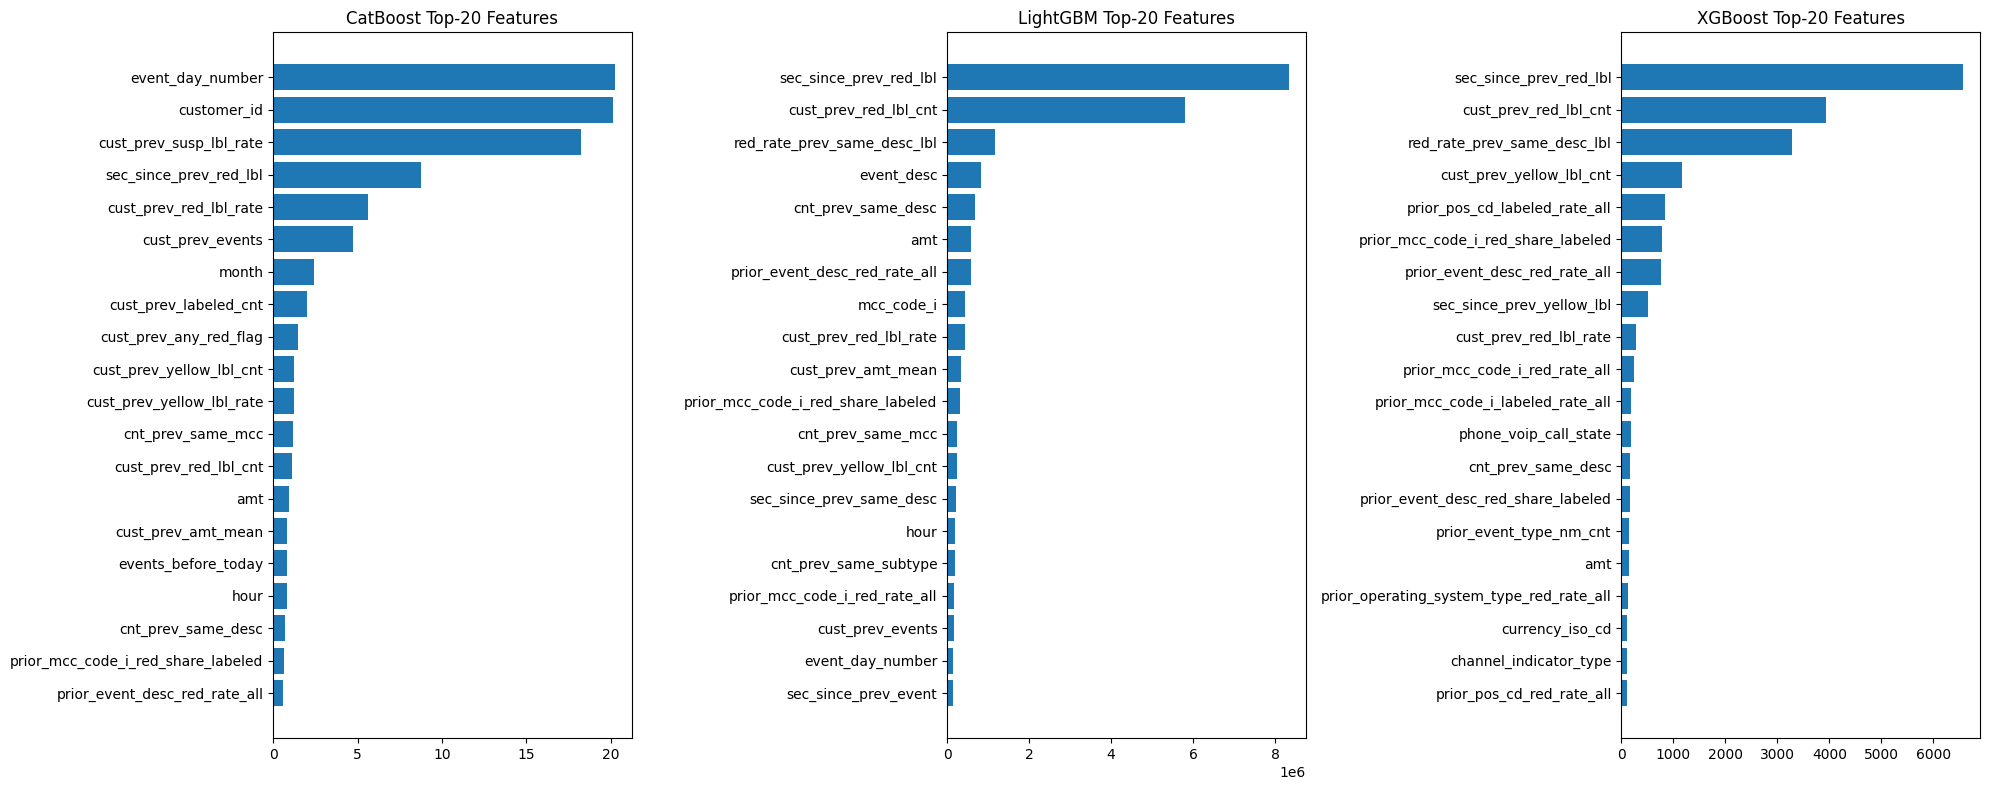

In [18]:
# ==================== FEATURE IMPORTANCE ====================
import matplotlib.pyplot as plt

# Reload models for importance analysis
model_cb = CatBoostClassifier().load_model(str(BOOST_CACHE_DIR / "cb_main.cbm"))
cb_imp = model_cb.get_feature_importance()
cb_feat_imp = pd.DataFrame({"feature": feature_cols, "importance": cb_imp}).sort_values("importance", ascending=False)

model_lgb_imp = lgbm.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_main.txt"))
lgb_imp_raw = model_lgb_imp.feature_importance(importance_type="gain")
lgb_feat_imp = pd.DataFrame({"feature": feature_cols, "importance": lgb_imp_raw}).sort_values("importance", ascending=False)

model_xgb_imp = xgb.Booster()
model_xgb_imp.load_model(str(BOOST_CACHE_DIR / "xgb_main.json"))
xgb_imp_dict = model_xgb_imp.get_score(importance_type="gain")
xgb_feat_imp = pd.DataFrame([
    {"feature": f, "importance": xgb_imp_dict.get(f, 0.0)} for f in feature_cols
]).sort_values("importance", ascending=False)

del model_cb, model_lgb_imp, model_xgb_imp; gc.collect()

# Plot top-20 for each
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, df_imp, title in zip(axes, [cb_feat_imp, lgb_feat_imp, xgb_feat_imp], ["CatBoost", "LightGBM", "XGBoost"]):
    top = df_imp.head(20)
    ax.barh(top["feature"].values[::-1], top["importance"].values[::-1])
    ax.set_title(f"{title} Top-20 Features")
plt.tight_layout()
plt.show()

In [19]:
# ==================== RESULTS TABLE ====================

results = pd.DataFrame({
    "Model": [
        "CatBoost Main", "CatBoost Blend (3-comp)",
        "LightGBM Main", "LightGBM Blend (3-comp)",
        "XGBoost Main", "XGBoost Blend (3-comp)",
        "Meta-Blend (rank-space)",
    ],
    "Val PR-AUC": [
        ap_cb_main, best_ap_cb,
        ap_lgb_main, best_ap_lgb,
        ap_xgb_main, best_ap_xgb,
        best_meta_ap,
    ],
})
results["Val PR-AUC"] = results["Val PR-AUC"].apply(lambda x: f"{x:.6f}")
print(results.to_string(index=False))

print(f"\nCatBoost blend weights:  {best_w_cb}")
print(f"LightGBM blend weights:  {best_w_lgb}")
print(f"XGBoost blend weights:   {best_w_xgb}")
print(f"Meta-blend weights:      {best_meta_w}")

                  Model Val PR-AUC
          CatBoost Main   0.436274
CatBoost Blend (3-comp)   0.452885
          LightGBM Main   0.471807
LightGBM Blend (3-comp)   0.476053
           XGBoost Main   0.453400
 XGBoost Blend (3-comp)   0.465841
Meta-Blend (rank-space)   0.476615

CatBoost blend weights:  (0.02, 0.48, 0.5)
LightGBM blend weights:  (0.3, 0.3, 0.4)
XGBoost blend weights:   (0.4, 0.14, 0.46)
Meta-blend weights:      (0.1, 0.8, 0.1)
